In [2]:
import numpy as np
import matplotlib.pyplot as plt

path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/"

path1 =  f'{path}Multi_thuth_3D_2023-12-16_19:00:00_temp1_alpha1_Loc5_True17_kindDEN4.npz'
path2 =  f'{path}Multi_thuth_3D_2023-12-16_19:00:00_temp2_alpha1_Loc5_True17_kindDEN4.npz'
path3 =  f'{path}Multi_thuth_3D_2023-12-16_19:00:00_temp3_alpha1_Loc5_True17_kindDEN4.npz'
                 #Multi_thuth_3D_2023-12-16_19:00:00_temp3_alpha1_Loc5_True17_kindDEN4.npz
data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)

xa1    = data1['xa'][:]
yo1    = data1['yo'][:]
atemp1 = data1['steps'][:]
ox1,oy1,oz1 = data1['ox'][:], data1['oy'][:], data1['oz'][:]
deps1 = data1['deps'][:]
print('deps1', deps1.shape)
print('Shape xa1', xa1.shape)
print(f'yo {yo1.shape}')
print(f'steps {atemp1}')

xa2    = data2['xa'][:]
yo2    = data2['yo'][:]
atemp2 = data2['steps'][:]
ox2,oy2,oz2 = data2['ox'][:], data2['oy'][:], data2['oz'][:]
deps2 = data2['deps'][:]
print('Shape xa2', xa2.shape)
print(f'yo {yo2.shape}')
print(f'steps {atemp2}')

xa3    = data3['xa'][:]
yo3    = data3['yo'][:]
atemp3 = data3['steps'][:]
ox3,oy3,oz3 = data3['ox'][:], data3['oy'][:], data3['oz'][:]
deps3 = data3['deps'][:]
print('Shape xa3', xa3.shape)
print(f'yo3 {yo3.shape}')
print(f'steps {atemp3}')

deps1 (1, 1278)
Shape xa1 (106, 116, 43, 29, 8)
yo (1278,)
steps [1.]
Shape xa2 (106, 116, 43, 29, 8)
yo (1278,)
steps [0.18242553 0.8175745 ]
Shape xa3 (106, 116, 43, 29, 8)
yo3 (1278,)
steps [0.04389628 0.3243521  0.6317516 ]


Loading data from /home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/Multi_thuth_3D_2023-12-16_19:00:00_temp1_alpha2_Loc5_True17_kindDEN4.npz...
Loading data from /home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/Multi_thuth_3D_2023-12-16_19:00:00_temp2_alpha2_Loc5_True17_kindDEN4.npz...
2-iter steps: [0.04742587 0.95257413]
Loading data from /home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/Multi_thuth_3D_2023-12-16_19:00:00_temp3_alpha2_Loc5_True17_kindDEN4.npz...
3-iter steps: [0.00380626 0.20781451 0.78837925]
Data loaded.
Calculating 3D reflectivity fields...


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/numpy/lib/function_base.py:2197: RuntimeWarning: divide by zero encountered in ? (vectorized)
  outputs = ufunc(*inputs)


Generating 4x3 plot with truth contours...


<ipython-input-3-a274c513f4b8>:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.0, rect=[0, 0, 0.9, 1])


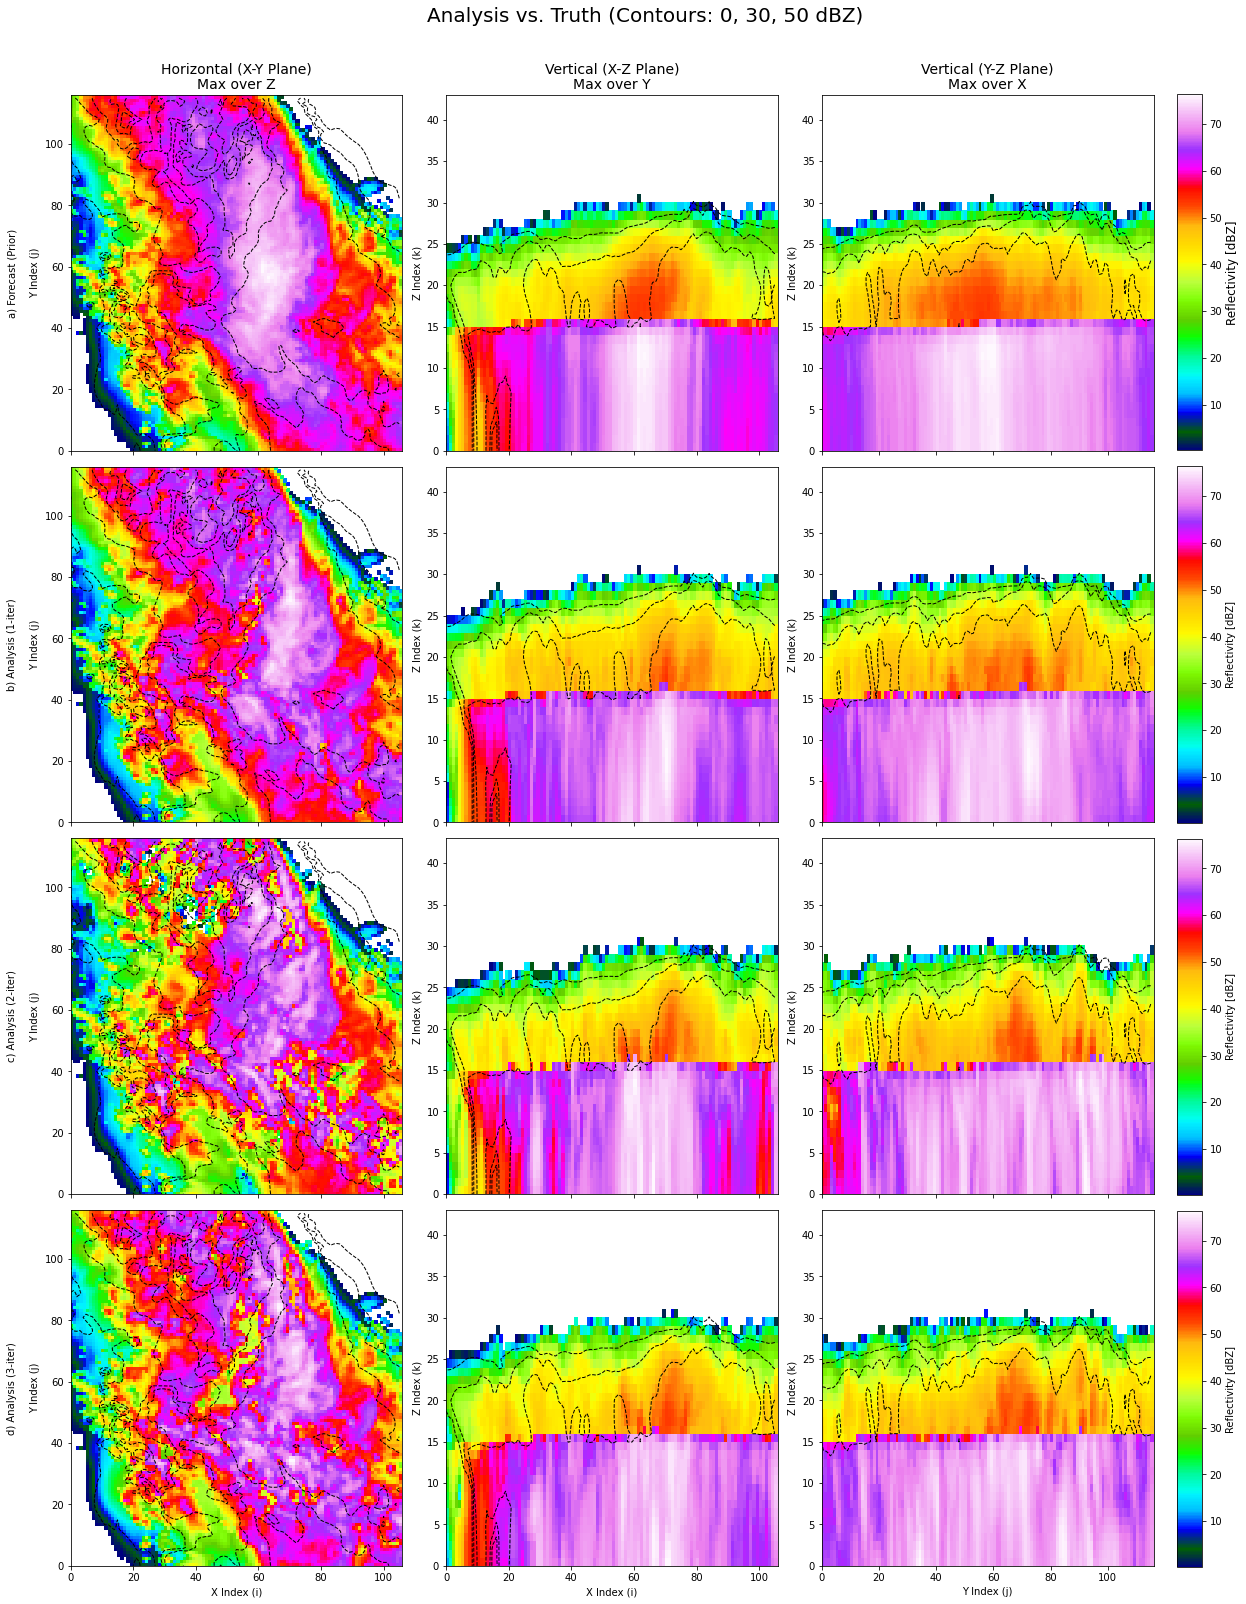

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import os
import sys
sys.path.append(os.path.join(os.getcwd(), "../src"))
sys.path.append(os.path.join(os.getcwd(), "../src/fortran"))
sys.path.append(os.path.join(os.getcwd(), "../src/runners"))
from cletkf_wloc import common_da as cda

# This is the function from your Fortran wrapper
calc_ref_scalar = cda.calc_ref

# We create a vectorized version for speed.
# This lets us feed it entire arrays instead of looping.
vectorized_calc_ref = np.vectorize(
    calc_ref_scalar, 
    doc="Vectorized version of the FORTRAN calc_ref function"
)

#----------------------------------------------------------------------
## 1. USER CONFIGURATION
#----------------------------------------------------------------------

VAR_IDX = {
    'qr': 0, 'qs': 1, 'qg': 2, 'T': 3, 'P': 4,
    'u': 5, 'v': 6, 'w': 7
}


base_path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/"
date_str = "2023-12-16_19:00:00"
alpha_str = "alpha2" # Or whatever alpha you used
loc_str = "Loc5"
true_str = "True17"
kind_str = "DEN4"

file_1_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp1_{alpha_str}_{loc_str}_{true_str}_kind{kind_str}.npz"
file_2_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp2_{alpha_str}_{loc_str}_{true_str}_kind{kind_str}.npz"
file_3_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp3_{alpha_str}_{loc_str}_{true_str}_kind{kind_str}.npz"


# Plotting range for reflectivity
vmin = 5
vmax = 70
cmap = "gist_ncar" # This is a good colormap for reflectivity

#----------------------------------------------------------------------
## 2. HELPER FUNCTION (Calculates 3D Reflectivity Field)
#----------------------------------------------------------------------

def get_ref_field_3d(state_data, var_idx, is_ensemble=False):
    """
    Calculates a 3D (nx, ny, nz) reflectivity field from a state array.
    
    Args:
        state_data: The state array (e.g., truth, xf, xa)
        var_idx: Your variable index dictionary
        is_ensemble: Set to True if data is (nx,ny,nz,Ne,nvar)
                     Set to False if data is (nx,ny,nz,nvar) like truth
    """
    
    # 1. Get the mean state
    if is_ensemble:
        # Calculate mean across ensemble (axis 3)
        mean_state = np.mean(state_data, axis=3) # Shape: (nx, ny, nz, nvar)
    else:
        mean_state = state_data # Shape: (nx, ny, nz, nvar)
        
    # 2. Get variables needed for reflectivity
    qr = mean_state[..., var_idx['qr']]
    qs = mean_state[..., var_idx['qs']]
    qg = mean_state[..., var_idx['qg']]
    TT = mean_state[..., var_idx['T']]
    PP = mean_state[..., var_idx['P']]
    
    # 4. Calculate reflectivity everywhere at once
    ref_field = vectorized_calc_ref(qr, qs, qg, TT, PP)
    
    return ref_field # Shape: (nx, ny, nz)

#----------------------------------------------------------------------
## 3. LOAD DATA
#----------------------------------------------------------------------
print(f"Loading data from {file_1_iter}...")
data_1 = np.load(file_1_iter)
truth = data_1['truth']
xf = data_1['xf']
xa_1 = data_1['xa'] # Analysis from 1-iter run

print(f"Loading data from {file_2_iter}...")
data_2 = np.load(file_2_iter)
xa_2 = data_2['xa'] # Analysis from 2-iter run
print(f"2-iter steps: {data_2['steps']}") # Check that this is more than [1.]

print(f"Loading data from {file_3_iter}...")
data_3 = np.load(file_3_iter)
xa_3 = data_3['xa'] # Analysis from 3-iter run
print(f"3-iter steps: {data_3['steps']}") # Check this too

print("Data loaded.")

#----------------------------------------------------------------------
## 4. GENERATE 3D REFLECTIVITY FIELDS
#----------------------------------------------------------------------
print("Calculating 3D reflectivity fields...")
ref_truth = get_ref_field_3d(truth, VAR_IDX, is_ensemble=False)
ref_forecast = get_ref_field_3d(xf, VAR_IDX, is_ensemble=True)
ref_anl_1 = get_ref_field_3d(xa_1, VAR_IDX, is_ensemble=True)
ref_anl_2 = get_ref_field_3d(xa_2, VAR_IDX, is_ensemble=True)
ref_anl_3 = get_ref_field_3d(xa_3, VAR_IDX, is_ensemble=True)

data_list = [ref_truth, ref_forecast, ref_anl_1, ref_anl_2, ref_anl_3]
row_titles = [
    'a) Truth', 'b) Forecast (Prior)',
    'c) Analysis (1-iter)', 'd) Analysis (2-iter)',
    'e) Analysis (3-iter)'
]
col_titles = [
    'Horizontal (X-Y Plane)\nMax over Z',
    'Vertical (X-Z Plane)\nMax over Y',
    'Vertical (Y-Z Plane)\nMax over X'
]

#----------------------------------------------------------------------
## 5. CREATE THE 5x3 PLOT
#----------------------------------------------------------------------

print("Generating 4x3 plot with truth contours...")

# List of data for shading (pcolormesh)
data_list_main = [ref_forecast, ref_anl_1, ref_anl_2, ref_anl_3]

# Titles for the new 4 rows
row_titles = [
    'a) Forecast (Prior)',
    'b) Analysis (1-iter)',
    'c) Analysis (2-iter)',
    'd) Analysis (3-iter)'
]
col_titles = [
    'Horizontal (X-Y Plane)\nMax over Z',
    'Vertical (X-Z Plane)\nMax over Y',
    'Vertical (Y-Z Plane)\nMax over X'
]

# --- Pre-calculate the Truth views for contours ---
truth_xy_view = np.max(ref_truth, axis=2).T
truth_xz_view = np.max(ref_truth, axis=1).T
truth_yz_view = np.max(ref_truth, axis=0).T

# --- Contour settings ---
contour_levels = [0, 30, 50]  # Your requested levels
contour_colors = 'black'       # Color for all contour lines
contour_style = 'dashed'     # 'solid', 'dashed', 'dotted'
contour_width = 1.0          # Line width

# --- Create the Figure ---
fig, axes = plt.subplots(
    nrows=4, ncols=3, 
    figsize=(18, 22), # Adjusted figure size
    sharex='col', sharey='col' # Share axes per-column
)

# Define normalization for the colormap (same as before)
norm = colors.Normalize(vmin=vmin, vmax=vmax)
im = None # To hold the image for the colorbar

for i, (ref_3d, row_title) in enumerate(zip(data_list_main, row_titles)):
    # ref_3d shape is (nx, ny, nz)
    
    # --- Column 0: Horizontal (X-Y) View ---
    ax_xy = axes[i, 0]
    xy_view = np.ma.masked_less(np.max(ref_3d, axis=2).T,0)  # Mask negative values for better visualization 
    im = ax_xy.pcolormesh(xy_view, cmap=cmap, shading='auto')
    # Add Truth Contours
    ax_xy.contour(
        truth_xy_view, 
        levels=contour_levels, 
        colors=contour_colors,
        linewidths=contour_width,
        linestyles=contour_style
    )
    ax_xy.set_ylabel(f'{row_title}\n\nY Index (j)')

    # --- Column 1: Vertical (X-Z) View ---
    ax_xz = axes[i, 1]
    xz_view = np.ma.masked_less(np.max(ref_3d, axis=1).T,0)  # Mask negative values for better visualization
    im = ax_xz.pcolormesh(xz_view, cmap=cmap, shading='auto')
    # Add Truth Contours
    ax_xz.contour(
        truth_xz_view, 
        levels=contour_levels, 
        colors=contour_colors,
        linewidths=contour_width,
        linestyles=contour_style
    )
    ax_xz.set_ylabel('Z Index (k)')

    # --- Column 2: Vertical (Y-Z) View ---
    ax_yz = axes[i, 2]
    yz_view = np.ma.masked_less(np.max(ref_3d, axis=0).T,0)  # Mask negative values for better visualization
    im = ax_yz.pcolormesh(yz_view, cmap=cmap, shading='auto')
    # Add Truth Contours
    ax_yz.contour(
        truth_yz_view, 
        levels=contour_levels, 
        colors=contour_colors,
        linewidths=contour_width,
        linestyles=contour_style
    )
    ax_yz.set_ylabel('Z Index (k)')
    
    # Set column titles on the first row
    if i == 0:
        ax_xy.set_title(col_titles[0], fontsize=14)
        ax_xz.set_title(col_titles[1], fontsize=14)
        ax_yz.set_title(col_titles[2], fontsize=14)

# Set x-labels on the LAST row (which is now index 3)
axes[3, 0].set_xlabel('X Index (i)')
axes[3, 1].set_xlabel('X Index (i)')
axes[3, 2].set_xlabel('Y Index (j)')

# Add a single, shared colorbar

cbar_axis1 = fig.add_axes([0.91, 0.025, 0.02, 0.225])  # [left, bottom, width, height]
cbar_axis2 = fig.add_axes([0.91, 0.260, 0.02, 0.225])  # [left, bottom, width, height]
cbar_axis3 = fig.add_axes([0.91, 0.495, 0.02, 0.225])  # [left, bottom, width, height]
cbar_axis4 = fig.add_axes([0.91, 0.730, 0.02, 0.225])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_axis1, orientation="vertical", label="Reflectivity [dBZ]")
cbar = fig.colorbar(im, cax=cbar_axis2, orientation="vertical", label="Reflectivity [dBZ]")
cbar = fig.colorbar(im, cax=cbar_axis3, orientation="vertical", label="Reflectivity [dBZ]")
cbar = fig.colorbar(im, cax=cbar_axis4, orientation="vertical", label="Reflectivity [dBZ]")
#cbar = fig.colorbar(
#    im, 
#    ax=axes.ravel().tolist(), 
#    label='Reflectivity [dBZ]',
#    shrink=0.5,
#    pad=0.02,
#    aspect=30
#)
cbar.set_label('Reflectivity [dBZ]', size=12)

fig.suptitle('Analysis vs. Truth (Contours: 0, 30, 50 dBZ)', fontsize=20, y=1.01)
plt.tight_layout(pad=1.0, rect=[0, 0, 0.9, 1])
plt.show()

Loading data from /home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/Multi_thuth_3D_2023-12-16_19:00:00_temp1_alpha2_Loc5_True17_kindDEN4.npz...


Loading data from /home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/Multi_thuth_3D_2023-12-16_19:00:00_temp2_alpha2_Loc5_True17_kindDEN4.npz...
Loading data from /home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/Multi_thuth_3D_2023-12-16_19:00:00_temp3_alpha2_Loc5_True17_kindDEN4.npz...
Data loaded. Found 43 vertical levels.
Calculating all vertical profiles...
  ... processing qg
  ... processing w
Calculations complete.
Generating plot...


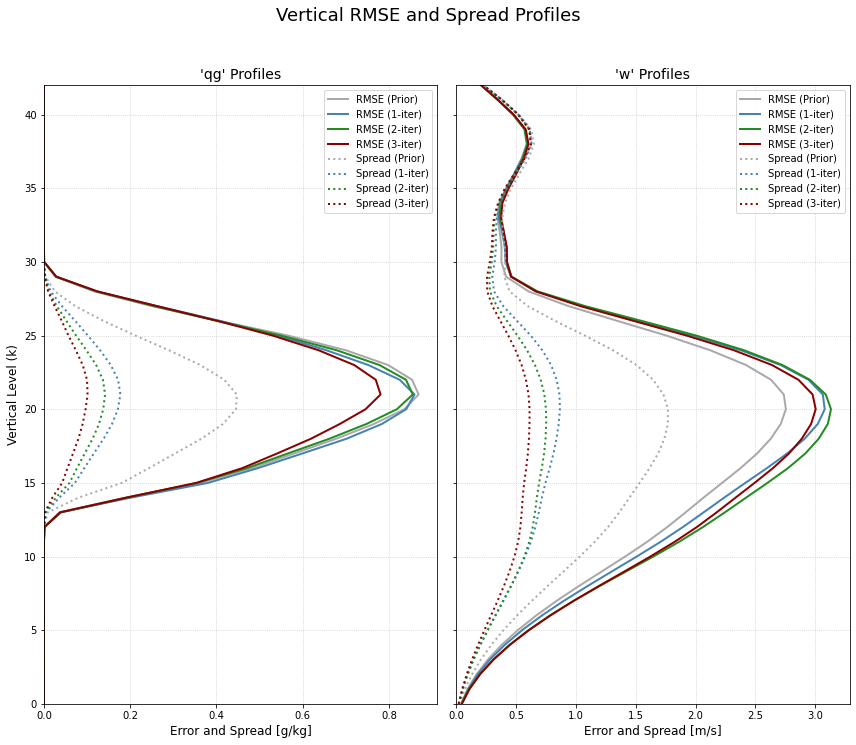

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from collections import defaultdict

#----------------------------------------------------------------------
## 1. USER CONFIGURATION (Please Edit This Section)
#----------------------------------------------------------------------

# ❗ IMPORTANT: Update this to match your config.yml
VAR_IDX = {
    'qr': 0, 'qs': 1, 'qg': 2, 'T': 3, 'P': 4,
    'u': 5, 'v': 6, 'w': 7
}

# ❗ Point these to your THREE DIFFERENT output files
base_path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/"
date_str = "2023-12-16_19:00:00"
alpha_str = "alpha2" # Or whatever alpha you used
loc_str = "Loc5"
true_str = "True17"
kind_str = "DEN4"

file_1_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp1_{alpha_str}_{loc_str}_{true_str}_kind{kind_str}.npz"
file_2_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp2_{alpha_str}_{loc_str}_{true_str}_kind{kind_str}.npz"
file_3_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp3_{alpha_str}_{loc_str}_{true_str}_kind{kind_str}.npz"

# --- Variables to Plot ---
# We'll plot 'qg' (graupel) and 'w' (vertical velocity)
vars_to_plot = ['qg', 'w']

# --- Units and Scaling ---
# (kg/kg -> g/kg)
var_units = {
    'qg': 'g/kg', 'qr': 'g/kg', 'qs': 'g/kg',
    'w': 'm/s', 'u': 'm/s', 'v': 'm/s',
    'T': 'K', 'P': 'Pa'
}
# Apply a scale factor (e.g., 1000 for kg/kg -> g/kg)
scale_factors = {
    'qg': 1000.0, 'qr': 1000.0, 'qs': 1000.0,
    'w': 1.0, 'u': 1.0, 'v': 1.0,
    'T': 1.0, 'P': 1.0
}

#----------------------------------------------------------------------
## 2. LOAD DATA
#----------------------------------------------------------------------
print(f"Loading data from {file_1_iter}...")
data_1 = np.load(file_1_iter)
truth = data_1['truth']
xf = data_1['xf']
xa_1 = data_1['xa'] # Analysis from 1-iter run

print(f"Loading data from {file_2_iter}...")
xa_2 = np.load(file_2_iter)['xa'] # Analysis from 2-iter run

print(f"Loading data from {file_3_iter}...")
xa_3 = np.load(file_3_iter)['xa'] # Analysis from 3-iter run

nz = truth.shape[2] # Number of vertical levels
y_levels = np.arange(nz)

print(f"Data loaded. Found {nz} vertical levels.")

#----------------------------------------------------------------------
## 3. HELPER FUNCTION
#----------------------------------------------------------------------

def calculate_vertical_profiles(state_truth, state_ensemble, var_idx, var_name, scale=1.0):
    """
    Calculates the horizontally-averaged RMSE and Spread profiles for a variable.
    """
    # Get the index for the variable
    idx = var_idx[var_name]
    
    # Extract the 3D variable field for truth
    # Shape: (nx, ny, nz)
    truth_var = state_truth[..., idx] * scale
    
    # Extract the 4D variable field for the ensemble
    # Shape: (nx, ny, nz, Ne)
    ens_var = state_ensemble[..., idx] * scale
    
    # Calculate ensemble mean and spread
    # Shapes: (nx, ny, nz)
    ens_mean = np.mean(ens_var, axis=3)
    ens_spread = np.std(ens_var, axis=3, ddof=1) # ddof=1 for sample stdev
    
    # Calculate squared error
    # Shape: (nx, ny, nz)
    error_sq = (ens_mean - truth_var)**2
    
    # --- Calculate Profiles ---
    # Average over the horizontal (axes 0 and 1) to get one value per vertical level
    
    # RMSE Profile: sqrt( mean( (mean(ens) - truth)^2 ) )
    # Shape: (nz,)
    rmse_profile = np.sqrt(np.mean(error_sq, axis=(0, 1)))
    
    # Spread Profile: mean( std(ens) )
    # Shape: (nz,)
    spread_profile = np.mean(ens_spread, axis=(0, 1))
    
    return rmse_profile, spread_profile

#----------------------------------------------------------------------
## 4. CALCULATE ALL PROFILES
#----------------------------------------------------------------------
print("Calculating all vertical profiles...")

# We will store results in a nested dictionary
all_profiles = defaultdict(dict)

for var in vars_to_plot:
    print(f"  ... processing {var}")
    scale = scale_factors.get(var, 1.0)
    
    # Prior (Forecast)
    rmse_prior, spread_prior = calculate_vertical_profiles(
        truth, xf, VAR_IDX, var, scale
    )
    all_profiles[var]['rmse_prior'] = rmse_prior
    all_profiles[var]['spread_prior'] = spread_prior

    # Analysis (1-iter)
    rmse_anl_1, spread_anl_1 = calculate_vertical_profiles(
        truth, xa_1, VAR_IDX, var, scale
    )
    all_profiles[var]['rmse_anl_1'] = rmse_anl_1
    all_profiles[var]['spread_anl_1'] = spread_anl_1

    # Analysis (2-iter)
    rmse_anl_2, spread_anl_2 = calculate_vertical_profiles(
        truth, xa_2, VAR_IDX, var, scale
    )
    all_profiles[var]['rmse_anl_2'] = rmse_anl_2
    all_profiles[var]['spread_anl_2'] = spread_anl_2

    # Analysis (3-iter)
    rmse_anl_3, spread_anl_3 = calculate_vertical_profiles(
        truth, xa_3, VAR_IDX, var, scale
    )
    all_profiles[var]['rmse_anl_3'] = rmse_anl_3
    all_profiles[var]['spread_anl_3'] = spread_anl_3

print("Calculations complete.")

#----------------------------------------------------------------------
## 5. CREATE THE PLOT
#----------------------------------------------------------------------
print("Generating plot...")

num_vars = len(vars_to_plot)
fig, axes = plt.subplots(
    nrows=1, ncols=num_vars, 
    figsize=(6 * num_vars, 10), 
    sharey=True # Share the vertical (k-level) axis
)

# Ensure 'axes' is an array even if num_vars=1
if num_vars == 1:
    axes = [axes]

for ax, var in zip(axes, vars_to_plot):
    profiles = all_profiles[var]
    
    # --- Plot RMSE ---
    ax.plot(profiles['rmse_prior'], y_levels, 
            label='RMSE (Prior)', color='DarkGrey', linestyle='-', linewidth=2)
    ax.plot(profiles['rmse_anl_1'], y_levels, 
            label='RMSE (1-iter)', color='SteelBlue', linestyle='-', linewidth=2)
    ax.plot(profiles['rmse_anl_2'], y_levels, 
            label='RMSE (2-iter)', color='ForestGreen', linestyle='-', linewidth=2)
    ax.plot(profiles['rmse_anl_3'], y_levels, 
            label='RMSE (3-iter)', color='DarkRed', linestyle='-', linewidth=2)
    
    # --- Plot Spread ---
    ax.plot(profiles['spread_prior'], y_levels, 
            label='Spread (Prior)', color='DarkGrey', linestyle=':', linewidth=2)
    ax.plot(profiles['spread_anl_1'], y_levels, 
            label='Spread (1-iter)', color='SteelBlue', linestyle=':', linewidth=2)
    ax.plot(profiles['spread_anl_2'], y_levels, 
        label='Spread (2-iter)', color='ForestGreen', linestyle=':', linewidth=2)
    ax.plot(profiles['spread_anl_3'], y_levels, 
        label='Spread (3-iter)', color='DarkRed', linestyle=':', linewidth=2)
    # --- Formatting ---
    ax.set_title(f"'{var}' Profiles", fontsize=14)
    ax.set_xlabel(f"Error and Spread [{var_units.get(var, 'N/A')}]", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.set_ylim(bottom=0, top=nz-1)
    ax.set_xlim(left=0) # Error cannot be negative
    
    if var == vars_to_plot[0]:
        ax.set_ylabel("Vertical Level (k)", fontsize=12)
        ax.legend()
    else:
        # Show legend on all plots if you prefer
        ax.legend()

fig.suptitle('Vertical RMSE and Spread Profiles', fontsize=18, y=1.03)
plt.tight_layout()
plt.show()

Loading data from /home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/Multi_thuth_3D_2023-12-16_19:00:00_temp1_alpha2_Loc5_True17_kindDEN4.npz...
Loading data from /home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/Multi_thuth_3D_2023-12-16_19:00:00_temp2_alpha2_Loc5_True17_kindDEN4.npz...
Loading data from /home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/Multi_thuth_3D_2023-12-16_19:00:00_temp3_alpha2_Loc5_True17_kindDEN4.npz...
Data loaded. Found 1278 observations.
Calculating prior H(x_f) for all obs... (This may take a moment)
Prior departure calculation complete.
Generating plot...


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/numpy/lib/function_base.py:2197: RuntimeWarning: divide by zero encountered in ? (vectorized)
  outputs = ufunc(*inputs)


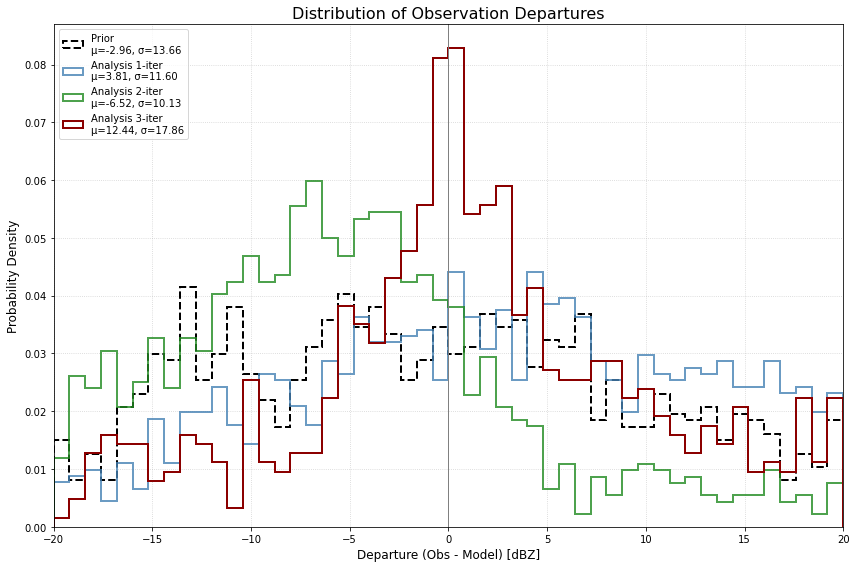

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.stats import norm

# --- Import your reflectivity calculator ---
# Make sure "src" is in your path
import sys
sys.path.append(os.path.join(os.getcwd(), "src"))
from cletkf_wloc import common_da as cda

# This is the function from your Fortran wrapper
calc_ref_scalar = cda.calc_ref

# We create a vectorized version for speed.
vectorized_calc_ref = np.vectorize(
    calc_ref_scalar, 
    doc="Vectorized version of the FORTRAN calc_ref function"
)

#----------------------------------------------------------------------
## 1. USER CONFIGURATION (Please Edit This Section)
#----------------------------------------------------------------------

# ❗ IMPORTANT: Update this to match your config.yml
VAR_IDX = {
    'qr': 0, 'qs': 1, 'qg': 2, 'T': 3, 'P': 4,
    'u': 5, 'v': 6, 'w': 7
}

# ❗ Point these to your THREE DIFFERENT output files
base_path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/"
date_str = "2023-12-16_19:00:00"
alpha_str = "alpha2" # Or whatever alpha you used
loc_str = "Loc5"
true_str = "True17"
kind_str = "DEN4"

file_1_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp1_{alpha_str}_{loc_str}_{true_str}_kind{kind_str}.npz"
file_2_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp2_{alpha_str}_{loc_str}_{true_str}_kind{kind_str}.npz"
file_3_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp3_{alpha_str}_{loc_str}_{true_str}_kind{kind_str}.npz"

# Plotting parameters
hist_bins = 50
hist_range = (-20, 20) # Plotting range for departures (dBZ)

#----------------------------------------------------------------------
## 2. HELPER FUNCTION (Calculates H(x) for ensemble)
#----------------------------------------------------------------------
def get_ens_h_of_x(state_ensemble, ox, oy, oz, var_idx):
    """
    Calculates H(x) (reflectivity) for all members at obs locations.
    
    Args:
        state_ensemble: (nx, ny, nz, Ne, nvar)
        ox, oy, oz: 1D arrays of obs locations (n_obs,)
        var_idx: Your variable index dictionary
        
    Returns:
        h_of_x: (n_obs, Ne) array of reflectivities
    """
    n_obs = ox.shape[0]
    Ne = state_ensemble.shape[3]
    h_of_x = np.empty((n_obs, Ne), dtype=np.float32)

    # Get state variables for all members at obs points
    # Shape of ens_at_obs: (n_obs, Ne, nvar)
    ens_at_obs = state_ensemble[ox, oy, oz, :, :]

    # Loop over variables
    qr = ens_at_obs[..., var_idx['qr']] # (n_obs, Ne)
    qs = ens_at_obs[..., var_idx['qs']]
    qg = ens_at_obs[..., var_idx['qg']]
    TT = ens_at_obs[..., var_idx['T']]
    PP = ens_at_obs[..., var_idx['P']]
    
    # Calculate reflectivity for all obs/members at once
    h_of_x = vectorized_calc_ref(qr, qs, qg, TT, PP)
    
    return h_of_x # Shape (n_obs, Ne)

#----------------------------------------------------------------------
## 3. LOAD DATA
#----------------------------------------------------------------------
print(f"Loading data from {file_1_iter}...")
data_1 = np.load(file_1_iter)
xf = data_1['xf']   # Prior ensemble
yo = data_1['yo']   # Observations
ox = data_1['ox']   # Obs locations
oy = data_1['oy']
oz = data_1['oz']
# Get final departure from 1-iter run
deps_1 = data_1['deps'][-1, :] # Shape (n_obs,)

print(f"Loading data from {file_2_iter}...")
data_2 = np.load(file_2_iter)
deps_2 = data_2['deps'][-1, :] # Final departure from 2-iter run

print(f"Loading data from {file_3_iter}...")
data_3 = np.load(file_3_iter)
deps_3 = data_3['deps'][-1, :] # Final departure from 3-iter run

print(f"Data loaded. Found {yo.shape[0]} observations.")

#----------------------------------------------------------------------
## 4. CALCULATE PRIOR DEPARTURES (O-B)
#----------------------------------------------------------------------
print("Calculating prior H(x_f) for all obs... (This may take a moment)")
# H(x_f) shape: (n_obs, Ne)
h_of_x_f = get_ens_h_of_x(xf, ox, oy, oz, VAR_IDX)

# H(x_f)_mean shape: (n_obs,)
h_of_x_f_mean = np.mean(h_of_x_f, axis=1)

# Prior departures (O-B)
deps_prior = yo - h_of_x_f_mean
print("Prior departure calculation complete.")

#----------------------------------------------------------------------
## 5. CREATE THE PLOT
#----------------------------------------------------------------------
print("Generating plot...")

fig, ax = plt.subplots(figsize=(12, 8))

# Plot as density histograms
# (density=True means the area under the histogram sums to 1)
ax.hist(deps_prior, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Prior \nμ={deps_prior.mean():.2f}, σ={deps_prior.std():.2f}', 
        color='black', linestyle='--')

ax.hist(deps_1, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 1-iter \nμ={deps_1.mean():.2f}, σ={deps_1.std():.2f}', 
        color='SteelBlue', alpha=0.8)

ax.hist(deps_2, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 2-iter \nμ={deps_2.mean():.2f}, σ={deps_2.std():.2f}', 
        color='ForestGreen', alpha=0.8)

ax.hist(deps_3, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2, # Thicker line
        label=f'Analysis 3-iter \nμ={deps_3.mean():.2f}, σ={deps_3.std():.2f}', 
        color='DarkRed', alpha=1.0)

# --- Formatting ---
ax.set_title('Distribution of Observation Departures', fontsize=16)
ax.set_xlabel('Departure (Obs - Model) [dBZ]', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(hist_range) # Enforce x-axis limits

# Add a line at zero
ax.axvline(0, color='gray', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

# LOAD ALL 30 EXPERIMENTS

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import os
import sys
sys.path.append(os.path.join(os.getcwd(), "../src"))
sys.path.append(os.path.join(os.getcwd(), "../src/fortran"))
sys.path.append(os.path.join(os.getcwd(), "../src/runners"))

from cletkf_wloc import common_da as cda

# This is the function from your Fortran wrapper
calc_ref_scalar = cda.calc_ref

# We create a vectorized version for speed.
vectorized_calc_ref = np.vectorize(
    calc_ref_scalar, 
    doc="Vectorized version of the FORTRAN calc_ref function"
)

def get_ens_h_of_x(state_ensemble, ox, oy, oz, var_idx):
    """
    Calculates H(x) (reflectivity) for all members at obs locations.
    """
    n_obs = ox.shape[0]
    Ne = state_ensemble.shape[3]
    ens_at_obs = state_ensemble[ox, oy, oz, :, :]

    qr = ens_at_obs[..., var_idx['qr']]
    qs = ens_at_obs[..., var_idx['qs']]
    qg = ens_at_obs[..., var_idx['qg']]
    TT = ens_at_obs[..., var_idx['T']]
    PP = ens_at_obs[..., var_idx['P']]
    
    h_of_x = vectorized_calc_ref(qr, qs, qg, TT, PP)
    return h_of_x # Shape (n_obs, Ne)

VAR_IDX = {
    'qr': 0, 'qs': 1, 'qg': 2, 'T': 3, 'P': 4,
    'u': 5, 'v': 6, 'w': 7
}


base_path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full3dS/"
date_str = "2023-12-16_19:00:00"
alpha_str = "alpha2" 
kind_str = "DEN4"#"FULL_3D"
loc = "Loc5"

#----------------------------------------------------------------------
## 3. LOAD DATA & CALCULATE METRICS
#----------------------------------------------------------------------
deps_1 = np.array([])
deps_2 = np.array([])
deps_3 = np.array([])
deps_prior = np.array([])
for i in range(30):
    print(f"Processing truth = {i} ...")
    
    file_1_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp1_{alpha_str}_{loc}_True{i}_kind{kind_str}.npz"
    file_2_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp2_{alpha_str}_{loc}_True{i}_kind{kind_str}.npz"
    file_3_iter = f"{base_path}Multi_thuth_3D_{date_str}_temp3_{alpha_str}_{loc}_True{i}_kind{kind_str}.npz"

    data_1 = np.load(file_1_iter)
    xf = data_1['xf']   # Prior ensemble
    yo = data_1['yo']   # Observations
    ox = data_1['ox']   # Obs locations
    oy = data_1['oy']
    oz = data_1['oz']
    deps_1 = np.append(deps_1,data_1['deps'][-1, :]) # Final departure from 1-iter run

    data_2 = np.load(file_2_iter)
    deps_2 = np.append(deps_2,data_2['deps'][-1, :]) # Final departure from 3-iter run

    data_3 = np.load(file_3_iter)
    deps_3 = np.append(deps_3,data_3['deps'][-1, :]) # Final departure from 3-iter run
    #print(f"shape deps_3: {np.array(deps_3).shape}")

    h_of_x_f = get_ens_h_of_x(xf, ox, oy, oz, VAR_IDX)
    h_of_x_f_mean = np.mean(h_of_x_f, axis=1)
    deps_prior = np.append(deps_prior,yo - h_of_x_f_mean)


Processing truth = 0 ...


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/numpy/lib/function_base.py:2197: RuntimeWarning: divide by zero encountered in ? (vectorized)
  outputs = ufunc(*inputs)


Processing truth = 1 ...
Processing truth = 2 ...
Processing truth = 3 ...
Processing truth = 4 ...
Processing truth = 5 ...
Processing truth = 6 ...
Processing truth = 7 ...
Processing truth = 8 ...
Processing truth = 9 ...
Processing truth = 10 ...
Processing truth = 11 ...
Processing truth = 12 ...
Processing truth = 13 ...
Processing truth = 14 ...
Processing truth = 15 ...
Processing truth = 16 ...
Processing truth = 17 ...
Processing truth = 18 ...
Processing truth = 19 ...
Processing truth = 20 ...
Processing truth = 21 ...
Processing truth = 22 ...
Processing truth = 23 ...
Processing truth = 24 ...
Processing truth = 25 ...
Processing truth = 26 ...
Processing truth = 27 ...
Processing truth = 28 ...
Processing truth = 29 ...


Generating plot...


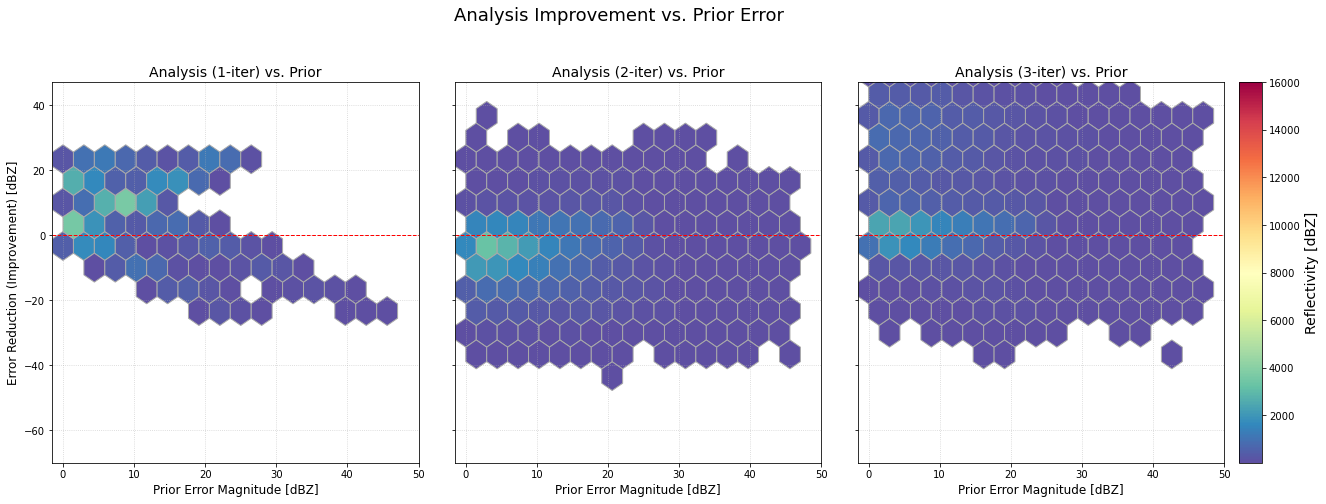

In [7]:
hex_gridsize = 17#(15,20)#25
# --- Calculate Metrics for Plotting ---
# X-axis: Prior Error Magnitude
prior_error_mag = np.abs(np.array(deps_prior))

# Y-axis: Error Reduction = |Prior Error| - |Analysis Error|
analysis_error_mag_1iter = np.abs(np.array(deps_1))
error_reduction_1iter = np.array(deps_1)#prior_error_mag - analysis_error_mag_1iter

analysis_error_mag_2iter = np.abs(np.array(deps_2))
error_reduction_2iter = np.array(deps_2)#prior_error_mag - analysis_error_mag_2iter

analysis_error_mag_3iter = np.abs(np.array(deps_3))
error_reduction_3iter = np.array(deps_3)#prior_error_mag - analysis_error_mag_3iter

#----------------------------------------------------------------------
## 4. CREATE THE PLOT
#----------------------------------------------------------------------
print("Generating plot...")

fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1, ncols=3, 
    figsize=(21, 7), 
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.1, 'wspace': 0.1}
)


ax1.set_ylim(-70,47)
ax1.set_xlim(-1.5,50)
# --- Plot 1: 1-Iteration Run ---
hb1 = ax1.hexbin(
    prior_error_mag, 
    error_reduction_1iter, 
    gridsize=hex_gridsize, 
    cmap='Spectral_r',edgecolors='Darkgrey',
    vmax=16000,
    mincnt=1, # Don't plot bins with 0 count
    extent=(0, 50, -70, 50)   
)
ax1.set_title('Analysis (1-iter) vs. Prior', fontsize=14)
ax1.set_ylabel('Error Reduction (Improvement) [dBZ]', fontsize=12)
ax1.set_xlabel('Prior Error Magnitude [dBZ]', fontsize=12)
ax1.axhline(0, color='red', linestyle='--', linewidth=1) # Degradation line
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: 3-Iteration Run ---
hb2 = ax2.hexbin(
    prior_error_mag, 
    error_reduction_2iter, 
    gridsize=hex_gridsize, 
    cmap='Spectral_r',edgecolors='Darkgrey',
    vmax=16000,
    mincnt=1, # Don't plot bins with 0 count
    extent=(0, 50, -70, 50)
)
ax2.set_title('Analysis (2-iter) vs. Prior', fontsize=14)
ax2.set_xlabel('Prior Error Magnitude [dBZ]', fontsize=12)
ax2.axhline(0, color='red', linestyle='--', linewidth=1)
ax2.grid(True, linestyle=':', alpha=0.6)


hb3 = ax3.hexbin(
    prior_error_mag, 
    error_reduction_3iter, 
    gridsize=hex_gridsize, 
    cmap='Spectral_r',edgecolors='Darkgrey',
    vmax=16000,
    mincnt=1, # Don't plot bins with 0 count
    extent=(0, 50, -70, 50)
)
ax3.set_title('Analysis (3-iter) vs. Prior', fontsize=14)
ax3.set_xlabel('Prior Error Magnitude [dBZ]', fontsize=12)
ax3.axhline(0, color='red', linestyle='--', linewidth=1)
ax3.grid(True, linestyle=':', alpha=0.6)

# Set shared limits
#ax1.set_xlim(0, x_max_err)
#ax1.set_ylim(-y_max_red/2, y_max_red) # Allow some negative y

# Add a shared colorbar
#fig.colorbar(hb1, ax=[ax1, ax2], label='Observation Count (Log Scale)')
cbar_axis = fig.add_axes([0.91, 0.125, 0.015, 0.755])  # [left, bottom, width, height]
cbar = fig.colorbar(hb3, cax=cbar_axis, orientation="vertical", label="Reflectivity [dBZ]")
cbar.set_label("Reflectivity [dBZ]", fontsize=14)
fig.suptitle('Analysis Improvement vs. Prior Error', fontsize=18, y=1.03)
#plt.tight_layout()
plt.show()

Generating plot...


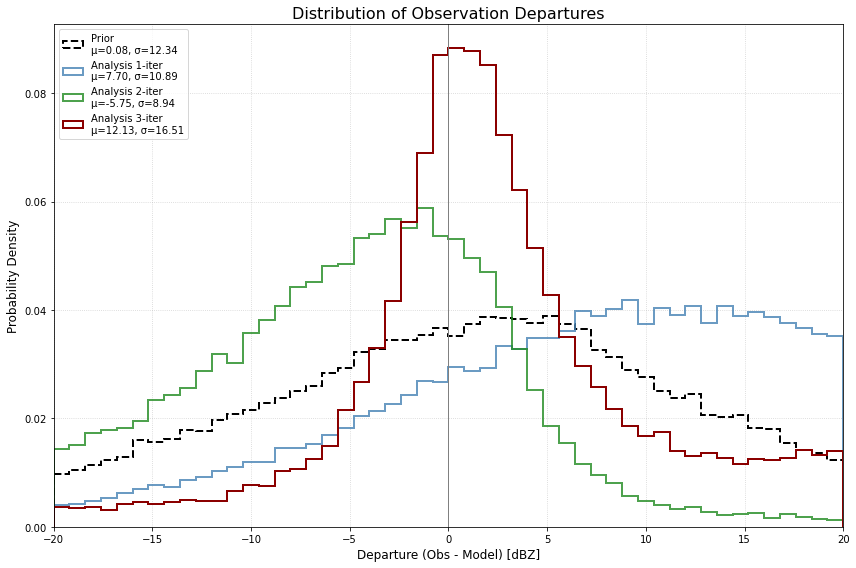

In [8]:
print("Generating plot...")

fig, ax = plt.subplots(figsize=(12, 8))

# Plot as density histograms
# (density=True means the area under the histogram sums to 1)
ax.hist(deps_prior, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Prior \nμ={deps_prior.mean():.2f}, σ={deps_prior.std():.2f}', 
        color='black', linestyle='--')

ax.hist(deps_1, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 1-iter \nμ={deps_1.mean():.2f}, σ={deps_1.std():.2f}', 
        color='SteelBlue', alpha=0.8)

ax.hist(deps_2, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 2-iter \nμ={deps_2.mean():.2f}, σ={deps_2.std():.2f}', 
        color='ForestGreen', alpha=0.8)

ax.hist(deps_3, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2, # Thicker line
        label=f'Analysis 3-iter \nμ={deps_3.mean():.2f}, σ={deps_3.std():.2f}', 
        color='DarkRed', alpha=1.0)

# --- Formatting ---
ax.set_title('Distribution of Observation Departures', fontsize=16)
ax.set_xlabel('Departure (Obs - Model) [dBZ]', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(hist_range) # Enforce x-axis limits

# Add a line at zero
ax.axvline(0, color='gray', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()